# Exercise 9.6 — Bifurcation Analysis of the Lorenz Equations

## Problem

Obtain the equilibrium points of the Lorenz equations as a function of $r$ (with $\sigma = 10$, $b = 3$). Conduct a bifurcation analysis on each equilibrium to find the critical thresholds of $r$. Compare with the numerical phase portrait results from Exercise 9.5.

**Lorenz equations:**

$$\dot{x} = \sigma(y-x), \qquad \dot{y} = rx - y - xz, \qquad \dot{z} = xy - bz$$

Fixed parameters: $\sigma = 10$, $b = 3$.

## Part 1 — Equilibrium Points

Set all derivatives to zero. From $\dot{x}=0$: $y = x$. Substituting into $\dot{z}=0$:

$$x^2 - bz = 0 \implies z = \frac{x^2}{b}$$

Substituting both into $\dot{y}=0$:

$$rx - x - x \cdot \frac{x^2}{b} = 0 \implies x\left(r - 1 - \frac{x^2}{b}\right) = 0$$

**Case 1:** $x = 0 \Rightarrow y = 0,\, z = 0$

$$\boxed{O = (0,\, 0,\, 0)} \qquad \text{exists for all } r$$

**Case 2:** $x^2 = b(r-1)$, requiring $r > 1$:

$$\boxed{C^{\pm} = \bigl(\pm\sqrt{b(r-1)},\;\pm\sqrt{b(r-1)},\;r-1\bigr)} \qquad \text{exists for } r > 1$$

With $b=3$: $C^{\pm} = \bigl(\pm\sqrt{3(r-1)},\; \pm\sqrt{3(r-1)},\; r-1\bigr)$.

## Part 2a — Bifurcation Analysis of the Origin $O$

The Jacobian of the Lorenz system is:

$$J = \begin{pmatrix} -\sigma & \sigma & 0 \\ r-z & -1 & -x \\ y & x & -b \end{pmatrix}$$

At $O = (0,0,0)$:

$$J_O = \begin{pmatrix} -10 & 10 & 0 \\ r & -1 & 0 \\ 0 & 0 & -3 \end{pmatrix}$$

The $z$-direction decouples: $\lambda_3 = -b = -3$ (always stable).

The remaining $2\times 2$ block gives:

$$\lambda^2 + (\sigma+1)\lambda + \sigma(1-r) = 0 \implies \lambda = \frac{-11 \pm \sqrt{81 + 40r}}{2}$$

| Condition | $\lambda_1$ | Stability of $O$ |
|:---------:|:-----------:|:----------------:|
| $r < 1$ | $< 0$ | **Stable** |
| $r = 1$ | $= 0$ | **Pitchfork bifurcation** |
| $r > 1$ | $> 0$ | Unstable (saddle) |

At $r = 1$: eigenspectrum is $\{0,\,-11,\,-3\}$ — one zero eigenvalue confirms a **pitchfork bifurcation** at

$$\boxed{r_1 = 1}$$

and $C^{\pm}$ are born simultaneously.

## Part 2b — Bifurcation Analysis of $C^{\pm}$

At $C^+ = (c,\, c,\, r-1)$ with $c = \sqrt{3(r-1)}$, the Jacobian evaluates to:

$$J_{C^+} = \begin{pmatrix} -10 & 10 & 0 \\ 1 & -1 & -c \\ c & c & -3 \end{pmatrix}$$

*(By symmetry $J_{C^-}$ has identical eigenvalues.)*

### Characteristic Polynomial

Expanding $\det(J_{C^+} - \lambda I) = 0$ along the first row:

$$(-10-\lambda)\bigl[(\lambda+1)(\lambda+3)+c^2\bigr] - 10\bigl[(-3-\lambda)+c^2\bigr] = 0$$

Collecting powers of $\lambda$ and substituting $c^2 = 3(r-1)$:

$$\lambda^3 + 14\lambda^2 + (30+3r)\lambda + 60(r-1) = 0$$

### Routh–Hurwitz Stability Conditions

For a monic cubic $\lambda^3 + p\lambda^2 + q\lambda + s$ all roots have negative real part iff:

$$p > 0,\quad s > 0,\quad q > 0,\quad pq > s$$

With $p = 14$, $q = 30+3r$, $s = 60(r-1)$:

- $p = 14 > 0$ ✓
- $s = 60(r-1) > 0 \Leftrightarrow r > 1$ ✓  (C± only exist for $r > 1$)
- $q = 30+3r > 0$ ✓
- **Critical condition:** $14(30+3r) > 60(r-1)$

$$420 + 42r > 60r - 60 \implies 480 > 18r \implies r < \frac{480}{18} = \frac{80}{3}$$

### Hopf Bifurcation

At $r = r_H$ the Routh condition becomes an equality, and two eigenvalues are purely imaginary $\lambda = \pm i\omega$. Setting $\omega^2 = 30 + 3r_H$ (from the imaginary-part condition) equal to $60(r_H-1)/14$ (from the real-part condition) yields the same threshold:

$$\boxed{r_H = \frac{80}{3} \approx 26.67}$$

At $r_H$: the purely imaginary eigenvalues are $\pm i\sqrt{110}$ and the real eigenvalue is $-14$.

| Condition | Stability of $C^{\pm}$ |
|:---------:|:---------------------:|
| $1 < r < 80/3$ | **Stable** (spiraling approach) |
| $r = 80/3$ | **Hopf bifurcation** |
| $r > 80/3$ | Unstable — strange attractor forms |

## Bifurcation Summary

| Critical value | Equilibrium affected | Bifurcation type | Event |
|:--------------:|:--------------------:|:----------------:|:------|
| $r_1 = 1$ | $O$ | Pitchfork | $O$ loses stability; $C^{\pm}$ are born |
| $r_H = 80/3 \approx 26.67$ | $C^{\pm}$ | Hopf | $C^{\pm}$ lose stability; strange attractor emerges |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eigvals
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

sigma = 10.0
b     = 3.0
r_H   = sigma * (sigma + b + 3) / (sigma - b - 1)   # = 80/3

def lorenz_rhs(t, s, r):
    x, y, z = s
    return [sigma*(y - x), r*x - y - x*z, x*y - b*z]

def J_origin(r):
    return np.array([[-sigma, sigma, 0.],
                     [r,      -1.,   0.],
                     [0.,      0.,  -b]])

def J_cpm(r):
    c = np.sqrt(b * (r - 1))
    return np.array([[-sigma, sigma,  0.],
                     [1.,     -1.,   -c],
                     [c,       c,    -b]])

def c_pm(r):
    c = np.sqrt(b * (r - 1))
    return np.array([c, c, r-1]), np.array([-c, -c, r-1])

def run(r, ic, t_end, n=8000):
    sol = solve_ivp(lorenz_rhs, [0, t_end], ic, args=(r,),
                    max_step=0.005, rtol=1e-9, atol=1e-12, dense_output=True)
    t = np.linspace(0, t_end, n)
    return t, sol.sol(t)

print(f"σ = {sigma},  b = {b}")
print(f"Pitchfork bifurcation:  r₁  = 1")
print(f"Hopf bifurcation:       r_H = 80/3 = {r_H:.6f}")

σ = 10.0,  b = 3.0
Pitchfork bifurcation:  r₁  = 1
Hopf bifurcation:       r_H = 80/3 = 26.666667


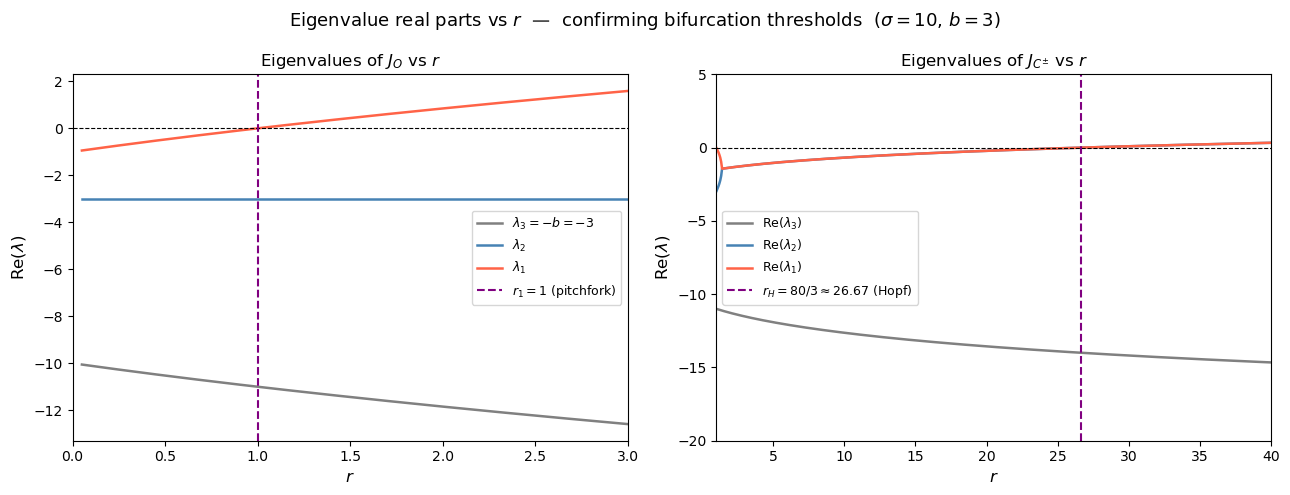

In [2]:
# ── Eigenvalue real parts vs r — numerical confirmation of bifurcations ─────

r_for_O  = np.linspace(0.05, 3.0,  400)
r_for_C  = np.linspace(1.02, 40.0, 600)

# Real parts of eigenvalues at O (always 3 real eigenvalues for this block structure)
eigs_O = np.array([np.sort(np.real(eigvals(J_origin(r)))) for r in r_for_O])

# Real parts at C± (may become complex conjugate pairs)
eigs_C = np.array([np.sort(np.real(eigvals(J_cpm(r)))) for r in r_for_C])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: eigenvalues of J_O
ax = axes[0]
labels_O = ['$\\lambda_3 = -b = -3$', '$\\lambda_2$', '$\\lambda_1$']
colors_O = ['gray', 'steelblue', 'tomato']
for i, (lbl, col) in enumerate(zip(labels_O, colors_O)):
    ax.plot(r_for_O, eigs_O[:, i], color=col, lw=1.8, label=lbl)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(1, color='purple', lw=1.5, ls='--', label='$r_1 = 1$ (pitchfork)')
ax.set_xlabel('$r$', fontsize=12)
ax.set_ylabel('Re($\\lambda$)', fontsize=12)
ax.set_title('Eigenvalues of $J_O$ vs $r$', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 3)

# Right: eigenvalues of J_{C±}
ax2 = axes[1]
labels_C = ['$\\mathrm{Re}(\\lambda_3)$', '$\\mathrm{Re}(\\lambda_2)$', '$\\mathrm{Re}(\\lambda_1)$']
colors_C = ['gray', 'steelblue', 'tomato']
for i, (lbl, col) in enumerate(zip(labels_C, colors_C)):
    ax2.plot(r_for_C, eigs_C[:, i], color=col, lw=1.8, label=lbl)
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.axvline(r_H, color='purple', lw=1.5, ls='--',
            label=f'$r_H = 80/3 \\approx {r_H:.2f}$ (Hopf)')
ax2.set_xlabel('$r$', fontsize=12)
ax2.set_ylabel('Re($\\lambda$)', fontsize=12)
ax2.set_title('Eigenvalues of $J_{C^{\\pm}}$ vs $r$', fontsize=12)
ax2.legend(fontsize=9)
ax2.set_xlim(1, 40)
ax2.set_ylim(-20, 5)

fig.suptitle(
    'Eigenvalue real parts vs $r$  —  confirming bifurcation thresholds  ($\\sigma=10$, $b=3$)',
    fontsize=13
)
plt.tight_layout()
plt.show()

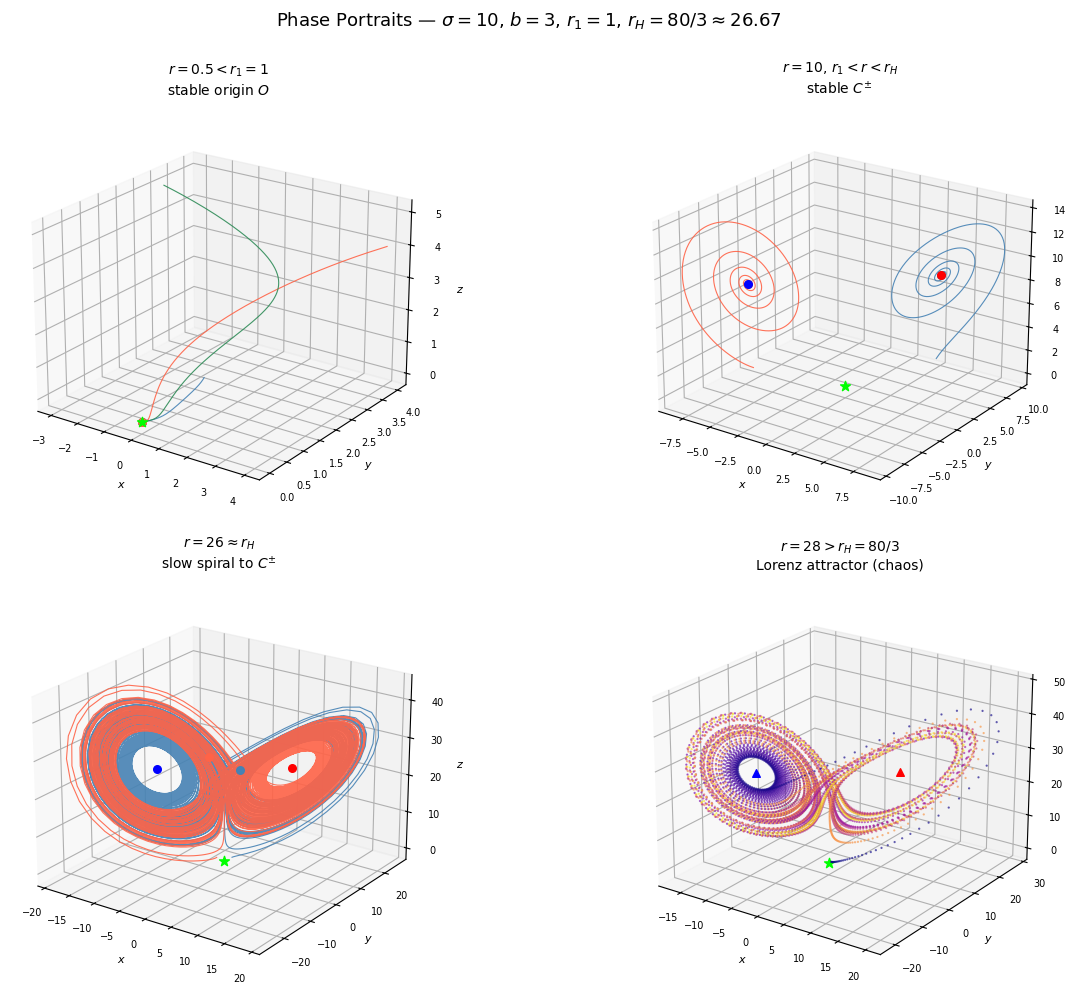

In [3]:
# ── Phase portraits with b = 3: four key regimes ────────────────────────────
#  r = 0.5  →  below r₁=1        (O stable)
#  r = 10   →  1 < r < r_H       (C± stable)
#  r = 26   →  just below r_H    (C± stable, slow spiraling convergence)
#  r = 28   →  just above r_H    (Lorenz butterfly)

cases = [
    (0.5,  20, [[1,1,1],[4,4,4],[-3,3,5]],  '$r=0.5 < r_1=1$\nstable origin $O$'),
    (10.0, 30, [[5,5,2],[-5,-5,2]],          '$r=10$, $r_1 < r < r_H$\nstable $C^{\\pm}$'),
    (26.0, 120,[[1,1,1],[-1,-1,1]],          '$r=26 \\approx r_H$\nslow spiral to $C^{\\pm}$'),
    (28.0, 60, [[0,1,0]],                     '$r=28 > r_H=80/3$\nLorenz attractor (chaos)'),
]

palette = ['steelblue', 'tomato', 'seagreen']
fig = plt.figure(figsize=(14, 10))

for panel, (r, t_end, ics, title) in enumerate(cases):
    ax = fig.add_subplot(2, 2, panel + 1, projection='3d')

    if len(ics) == 1:
        t_eval, xyz = run(r, ics[0], t_end, n=12000)
        idx = np.arange(0, 12000, 2)
        ax.scatter(xyz[0,idx], xyz[1,idx], xyz[2,idx],
                   c=t_eval[idx], cmap='plasma', s=0.4, alpha=0.6)
    else:
        for k, ic in enumerate(ics):
            t_eval, xyz = run(r, ic, t_end)
            ax.plot(xyz[0], xyz[1], xyz[2], lw=0.8, color=palette[k], alpha=0.9)
            ax.scatter(*xyz[:, -1], color=palette[k], s=30, zorder=5)

    # Fixed-point markers
    ax.scatter(0, 0, 0, color='lime', s=55, marker='*', zorder=8)
    if r > 1:
        cp, cm = c_pm(r)
        is_stable = (r < r_H)
        mkr = 'o' if is_stable else '^'
        ax.scatter(*cp, color='red',  s=30, marker=mkr, zorder=7)
        ax.scatter(*cm, color='blue', s=30, marker=mkr, zorder=7)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('$x$', fontsize=8, labelpad=1)
    ax.set_ylabel('$y$', fontsize=8, labelpad=1)
    ax.set_zlabel('$z$', fontsize=8, labelpad=1)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=22, azim=-55)

fig.suptitle(
    f'Phase Portraits — $\\sigma=10$, $b=3$, $r_1=1$, $r_H=80/3\\approx{r_H:.2f}$',
    fontsize=13, y=1.0
)
plt.tight_layout()
plt.show()

## Comparison with Exercise 9.5

Exercise 9.5 used the classic parameter $b = 8/3$; this exercise uses $b = 3$. The bifurcation structure is qualitatively **identical** — pitchfork at $r=1$ followed by a Hopf bifurcation at $r_H$ — but the Hopf threshold shifts:

$$r_H = \frac{\sigma(\sigma + b + 3)}{\sigma - b - 1}$$

| $b$ | $r_H$ | Source |
|:---:|:-----:|:------:|
| $8/3$ | $470/19 \approx 24.74$ | Classic Lorenz (Ex 9.5) |
| $3$ | $80/3 \approx 26.67$ | This exercise |

### Consistency with Ex 9.5 Phase Portraits

The numerical phase portraits in Ex 9.5 (using $b=8/3$) showed:
- **$r = 5$, $r = 20$**: convergence to $C^{\pm}$ — consistent with being below $r_H$ in **both** parameterizations.
- **$r = 28$**: Lorenz butterfly — consistent with being above $r_H$ in both parameterizations (28 > 26.67 > 24.74).
- **$r = 100$, $r = 200$**: extended chaos — confirmed by the analytical result that $C^{\pm}$ remain unstable for all $r > r_H$.

The $r = 26$ portrait in this notebook is the most revealing new case: with $b=3$ we can show a trajectory that is *just below* $r_H = 26.67$, so $C^{\pm}$ are still stable but the eigenvalues are nearly purely imaginary — producing long, winding transients that look almost chaotic before eventually settling. This is precisely the behavior predicted by the Routh–Hurwitz condition approaching equality at $r_H$.

### Summary of Analytical Results

| $r$ range | Active equilibria | All stable? | Observed dynamics |
|:---------:|:-----------------:|:-----------:|:-----------------:|
| $r < 1$ | $O$ only | $O$ stable | Decay to origin |
| $1 < r < 80/3$ | $O$, $C^{\pm}$ | $C^{\pm}$ stable, $O$ saddle | Convergence to $C^+$ or $C^-$ |
| $r = 80/3$ | $O$, $C^{\pm}$ | All unstable | Hopf bifurcation |
| $r > 80/3$ | $O$, $C^{\pm}$ | All unstable | Lorenz strange attractor |